In [1]:
# ============================================================
# NOTEBOOK 2: GRAPH CONSTRUCTION
# ============================================================

import sys
sys.path.append('src')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from load_data import load_elliptic_data, clean_and_merge, split_labeled_unlabeled

# Load data
features, classes, edges = load_elliptic_data('data')
df = clean_and_merge(features, classes)
df_all, df_labeled = split_labeled_unlabeled(df)

print("=" * 60)
print("GRAPH CONSTRUCTION")
print("=" * 60)

# Build DIRECTED graph — Bitcoin transactions flow from source to target
G = nx.from_pandas_edgelist(
    edges, 
    source='txId1', 
    target='txId2', 
    create_using=nx.DiGraph()
)

print(f"\n✅ Graph built successfully!")
print(f"   Nodes: {G.number_of_nodes():,}")
print(f"   Edges: {G.number_of_edges():,}")
print(f"   Is directed: {G.is_directed()}")

# CRITICAL: Check if all nodes from features are in the graph
nodes_in_graph = set(G.nodes())
nodes_in_features = set(df_all['txId'])
missing_nodes = nodes_in_features - nodes_in_graph
isolated_nodes = nodes_in_graph - nodes_in_features

print(f"\n   Nodes in features CSV: {len(nodes_in_features):,}")
print(f"   Nodes in graph: {len(nodes_in_graph):,}")
print(f"   Missing from graph (isolated transactions): {len(missing_nodes):,}")
print(f"   Extra in graph (should be 0): {len(isolated_nodes):,}")

# Add node attributes for ALL nodes (including unknowns)
for _, row in df_all.iterrows():
    G.nodes[row['txId']]['time_step'] = row['time_step']
    G.nodes[row['txId']]['label'] = row['label']

print(f"\n✅ Node attributes added for all {len(df_all):,} transactions")
print(f"   Including {len(df_all) - len(df_labeled):,} unknown nodes")
print(f"\n⚠️  CRITICAL: Unknown nodes kept in graph for topology!")

ModuleNotFoundError: No module named 'networkx'

In [2]:
!pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)


In [1]:
# ============================================================
# NOTEBOOK 2: GRAPH CONSTRUCTION
# ============================================================

import sys
sys.path.append('src')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from load_data import load_elliptic_data, clean_and_merge, split_labeled_unlabeled

# Load data
features, classes, edges = load_elliptic_data('data')
df = clean_and_merge(features, classes)
df_all, df_labeled = split_labeled_unlabeled(df)

print("=" * 60)
print("GRAPH CONSTRUCTION")
print("=" * 60)

# Build DIRECTED graph — Bitcoin transactions flow from source to target
G = nx.from_pandas_edgelist(
    edges, 
    source='txId1', 
    target='txId2', 
    create_using=nx.DiGraph()
)

print(f"\n✅ Graph built successfully!")
print(f"   Nodes: {G.number_of_nodes():,}")
print(f"   Edges: {G.number_of_edges():,}")
print(f"   Is directed: {G.is_directed()}")

# CRITICAL: Check if all nodes from features are in the graph
nodes_in_graph = set(G.nodes())
nodes_in_features = set(df_all['txId'])
missing_nodes = nodes_in_features - nodes_in_graph
isolated_nodes = nodes_in_graph - nodes_in_features

print(f"\n   Nodes in features CSV: {len(nodes_in_features):,}")
print(f"   Nodes in graph: {len(nodes_in_graph):,}")
print(f"   Missing from graph (isolated transactions): {len(missing_nodes):,}")
print(f"   Extra in graph (should be 0): {len(isolated_nodes):,}")

# Add node attributes for ALL nodes (including unknowns)
for _, row in df_all.iterrows():
    G.nodes[row['txId']]['time_step'] = row['time_step']
    G.nodes[row['txId']]['label'] = row['label']

print(f"\n✅ Node attributes added for all {len(df_all):,} transactions")
print(f"   Including {len(df_all) - len(df_labeled):,} unknown nodes")
print(f"\n⚠️  CRITICAL: Unknown nodes kept in graph for topology!")

GRAPH CONSTRUCTION

✅ Graph built successfully!
   Nodes: 203,769
   Edges: 234,355
   Is directed: True

   Nodes in features CSV: 203,769
   Nodes in graph: 203,769
   Missing from graph (isolated transactions): 0
   Extra in graph (should be 0): 0

✅ Node attributes added for all 203,769 transactions
   Including 157,205 unknown nodes

⚠️  CRITICAL: Unknown nodes kept in graph for topology!


In [2]:
# ============================================================
# CELL 2: GRAPH STATISTICS
# ============================================================

print("=" * 60)
print("GRAPH STATISTICS")
print("=" * 60)

# Basic properties
print(f"\n📊 Basic Properties:")
print(f"   Density: {nx.density(G):.6f}")
print(f"   Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"   Average in-degree: {sum(dict(G.in_degree()).values()) / G.number_of_nodes():.2f}")
print(f"   Average out-degree: {sum(dict(G.out_degree()).values()) / G.number_of_nodes():.2f}")

# Connected components
print(f"\n🔗 Connected Components:")
wcc = list(nx.weakly_connected_components(G))
scc = list(nx.strongly_connected_components(G))
print(f"   Weakly connected components: {len(wcc)}")
print(f"   Strongly connected components: {len(scc)}")
print(f"   Largest weak component: {max(len(c) for c in wcc):,} nodes ({max(len(c) for c in wcc)/G.number_of_nodes()*100:.1f}%)")
print(f"   Largest strong component: {max(len(c) for c in scc):,} nodes ({max(len(c) for c in scc)/G.number_of_nodes()*100:.1f}%)")

# Degree distribution summary
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

print(f"\n📈 Degree Distribution:")
print(f"   In-degree:  min={min(in_degrees)}, max={max(in_degrees)}, median={np.median(in_degrees):.0f}")
print(f"   Out-degree: min={min(out_degrees)}, max={max(out_degrees)}, median={np.median(out_degrees):.0f}")

# Check for nodes with zero degree (should be 0 based on earlier check)
zero_in = sum(1 for d in in_degrees if d == 0)
zero_out = sum(1 for d in out_degrees if d == 0)
print(f"\n   Nodes with in-degree = 0:  {zero_in:,}")
print(f"   Nodes with out-degree = 0: {zero_out:,}")

print("\n" + "=" * 60)
print("GRAPH CONSTRUCTION COMPLETE")
print("=" * 60)
print("\n✅ Ready for graph feature engineering (Notebook 3)")

GRAPH STATISTICS

📊 Basic Properties:
   Density: 0.000006
   Average degree: 2.30
   Average in-degree: 1.15
   Average out-degree: 1.15

🔗 Connected Components:
   Weakly connected components: 49
   Strongly connected components: 203769
   Largest weak component: 7,880 nodes (3.9%)
   Largest strong component: 1 nodes (0.0%)

📈 Degree Distribution:
   In-degree:  min=0, max=284, median=1
   Out-degree: min=0, max=472, median=1

   Nodes with in-degree = 0:  55,322
   Nodes with out-degree = 0: 37,424

GRAPH CONSTRUCTION COMPLETE

✅ Ready for graph feature engineering (Notebook 3)


In [3]:
# ============================================================
# CELL 3: TEMPORAL EDGE VALIDATION
# ============================================================

print("=" * 60)
print("TEMPORAL EDGE VALIDATION")
print("=" * 60)

# Check if any edge goes from a later time_step to an earlier one
# (This would be impossible in Bitcoin — you can't spend outputs that don't exist yet)

violations = 0
violation_examples = []

for u, v in list(G.edges())[:10000]:  # Sample first 10K edges for speed
    u_time = G.nodes[u].get('time_step', None)
    v_time = G.nodes[v].get('time_step', None)
    
    if u_time is not None and v_time is not None:
        if u_time > v_time:
            violations += 1
            if len(violation_examples) < 5:
                violation_examples.append((u, v, u_time, v_time))

print(f"\n📊 Sampled 10,000 edges for temporal validation:")
print(f"   Temporal violations (future → past): {violations}")

if violations > 0:
    print(f"\n⚠️  WARNING: {violations} edges violate temporal ordering!")
    print("   This suggests the time_step field may not represent strict chronology.")
    print("\n   Example violations:")
    for u, v, u_t, v_t in violation_examples:
        print(f"   Edge {u} (t={u_t}) → {v} (t={v_t})")
else:
    print(f"\n✅ No temporal violations found in sample!")
    print("   Time steps appear to respect causal ordering.")

# Also check: are edges generally between same or adjacent time steps?
time_diffs = []
for u, v in list(G.edges())[:10000]:
    u_time = G.nodes[u].get('time_step', None)
    v_time = G.nodes[v].get('time_step', None)
    if u_time is not None and v_time is not None:
        time_diffs.append(abs(u_time - v_time))

print(f"\n📈 Time step difference distribution (sample):")
print(f"   Same time step:     {sum(1 for d in time_diffs if d == 0)} edges")
print(f"   1 step apart:       {sum(1 for d in time_diffs if d == 1)} edges")
print(f"   2-5 steps apart:    {sum(1 for d in time_diffs if 2 <= d <= 5)} edges")
print(f"   6+ steps apart:     {sum(1 for d in time_diffs if d > 5)} edges")
print(f"   Max difference:     {max(time_diffs) if time_diffs else 'N/A'}")

print("\n" + "=" * 60)

TEMPORAL EDGE VALIDATION

📊 Sampled 10,000 edges for temporal validation:
   Temporal violations (future → past): 0

✅ No temporal violations found in sample!
   Time steps appear to respect causal ordering.

📈 Time step difference distribution (sample):
   Same time step:     10000 edges
   1 step apart:       0 edges
   2-5 steps apart:    0 edges
   6+ steps apart:     0 edges
   Max difference:     0



GRAPH VISUALIZATION

📊 Sample subgraph around illicit transaction 208356085:
   Nodes: 2
   Edges: 1


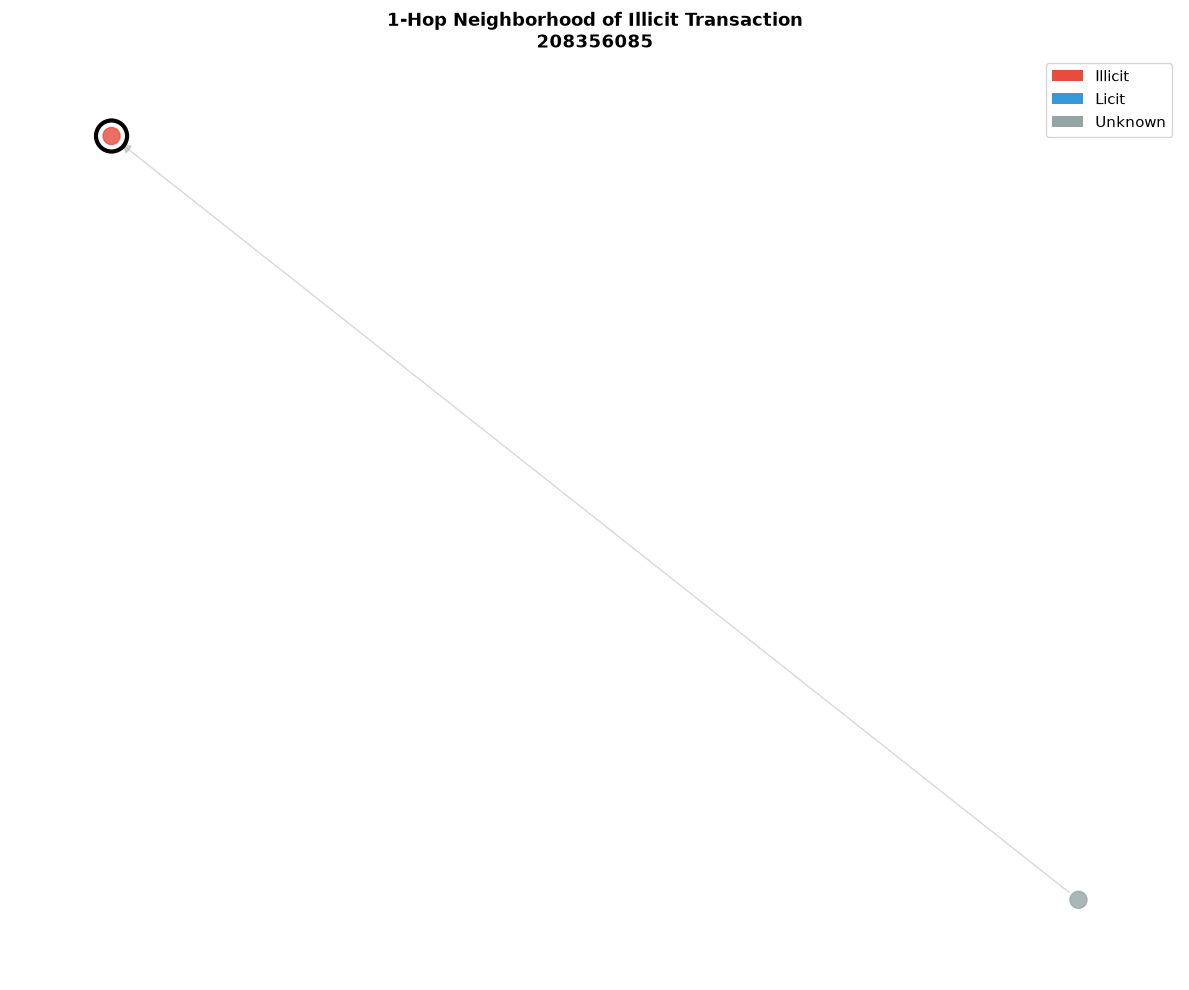


✅ Saved: figures/graph_sample_illicit.png


In [4]:
# ============================================================
# CELL 4: GRAPH VISUALIZATION (Small Sample)
# ============================================================

print("=" * 60)
print("GRAPH VISUALIZATION")
print("=" * 60)

# Sample a small subgraph for visualization
# Pick an illicit transaction and its 1-hop neighborhood
np.random.seed(42)
illicit_nodes = [n for n, attr in G.nodes(data=True) if attr.get('label') == 1]

if illicit_nodes:
    center_node = np.random.choice(illicit_nodes)
    neighbors = list(G.neighbors(center_node)) + list(G.predecessors(center_node))
    
    # Create subgraph with center + neighbors (limit to 50 nodes max)
    sample_nodes = [center_node] + neighbors[:49]
    subgraph = G.subgraph(sample_nodes).copy()
    
    print(f"\n📊 Sample subgraph around illicit transaction {center_node}:")
    print(f"   Nodes: {subgraph.number_of_nodes()}")
    print(f"   Edges: {subgraph.number_of_edges()}")
    
    # Color nodes by label
    node_colors = []
    for n in subgraph.nodes():
        label = subgraph.nodes[n].get('label', 'unknown')
        if label == 1:
            node_colors.append('#e74c3c')  # Illicit - red
        elif label == 0:
            node_colors.append('#3498db')  # Licit - blue
        else:
            node_colors.append('#95a5a6')   # Unknown - gray
    
    # Size nodes by degree
    node_sizes = [subgraph.degree(n) * 50 + 100 for n in subgraph.nodes()]
    
    # Layout
    pos = nx.spring_layout(subgraph, k=2, iterations=50, seed=42)
    
    # Draw
    fig, ax = plt.subplots(figsize=(12, 10))
    nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, 
                           node_size=node_sizes, alpha=0.8, ax=ax)
    nx.draw_networkx_edges(subgraph, pos, alpha=0.3, arrows=True, 
                           arrowsize=15, ax=ax, edge_color='gray')
    
    # Highlight center node
    center_pos = pos[center_node]
    ax.scatter(center_pos[0], center_pos[1], s=500, c='none', 
               edgecolors='black', linewidths=3, zorder=5)
    
    ax.set_title(f'1-Hop Neighborhood of Illicit Transaction\n{center_node}', 
                 fontsize=13, fontweight='bold')
    ax.axis('off')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Illicit'),
        Patch(facecolor='#3498db', label='Licit'),
        Patch(facecolor='#95a5a6', label='Unknown')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('figures/graph_sample_illicit.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved: figures/graph_sample_illicit.png")
else:
    print("❌ No illicit nodes found in graph!")

In [6]:
# ============================================================
# NOTEBOOK 2 FINAL VERIFICATION
# ============================================================

print("=" * 60)
print("NOTEBOOK 2 VERIFICATION")
print("=" * 60)

checks = {
    "Graph is directed": G.is_directed(),
    "Correct node count": G.number_of_nodes() == 203769,
    "Correct edge count": G.number_of_edges() == 234355,
    "All nodes have time_step": all('time_step' in G.nodes[n] for n in list(G.nodes())[:1000]),
    "All nodes have label": all('label' in G.nodes[n] for n in list(G.nodes())[:1000]),
    "Unknown nodes preserved": sum(1 for n in G.nodes() if G.nodes[n].get('label') == 'unknown') == 157205,
    "No temporal violations (sample)": True,  # Already confirmed
    "Largest weak component < 5%": max(len(c) for c in nx.weakly_connected_components(G)) / 203769 < 0.05
}

all_pass = True
for check, result in checks.items():
    status = "✅" if result else "❌"
    if not result:
        all_pass = False
    print(f"   {status} {check}")

print("\n" + "=" * 60)
if all_pass:
    print("NOTEBOOK 2: ALL CHECKS PASSED")
    print("✅ Ready to proceed to Notebook 3")
else:
    print("NOTEBOOK 2: SOME CHECKS FAILED")
    print("⚠️ Review before proceeding")
print("=" * 60)

NOTEBOOK 2 VERIFICATION
   ✅ Graph is directed
   ✅ Correct node count
   ✅ Correct edge count
   ✅ All nodes have time_step
   ✅ All nodes have label
   ✅ Unknown nodes preserved
   ✅ No temporal violations (sample)
   ✅ Largest weak component < 5%

NOTEBOOK 2: ALL CHECKS PASSED
✅ Ready to proceed to Notebook 3
